# Layer 1: Interannual Comparison 2024–2025

**Objective:** Compare temperature climatology across 2024 and 2025 to identify whether key features (T_min plateau, seasonal cycle) are consistent across years. This tests whether observed patterns are robust or year-specific artifacts.

## Question for H1

**H1 (dry-season amplification):** Is the T_min plateau more pronounced in the dry season (Dec–Mar)? Does it appear at the same calendar dates in both years?

## Section 1 — Load and Process Both Years

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Constants
CALI_LAT, CALI_LON = 3.45, -76.53

In [2]:
# Find repo root and set up data directories
current = Path.cwd()
while current != current.parent:
    if (current / "shared" / "data" / "raw" / "era5").is_dir():
        repo_root = current
        break
    current = current.parent
else:
    raise FileNotFoundError("Could not find repo root with shared/data/raw/era5")

data_2024_dir = repo_root / "shared" / "data" / "raw" / "era5" / "2024"
data_2025_dir = repo_root / "shared" / "data" / "raw" / "era5" / "2025"

assert data_2024_dir.is_dir(), f"2024 data directory not found: {data_2024_dir}"
assert data_2025_dir.is_dir(), f"2025 data directory not found: {data_2025_dir}"

t2m_files_2024 = sorted(data_2024_dir.glob("*t2m.nc"))
t2m_files_2025 = sorted(data_2025_dir.glob("*t2m.nc"))

assert len(t2m_files_2024) == 12, f"Expected 12 t2m files for 2024, found {len(t2m_files_2024)}"
assert len(t2m_files_2025) == 12, f"Expected 12 t2m files for 2025, found {len(t2m_files_2025)}"

print(f"✓ Found t2m data for 2024 and 2025")

✓ Found t2m data for 2024 and 2025


In [3]:
# Load and process t2m for both years
def load_and_process_year(t2m_files, year_label):
    """Load t2m files, convert to Celsius, shift to local time, extract reference point, build daily DataFrame."""
    # Load files
    datasets = [xr.open_dataset(f, engine="netcdf4") for f in t2m_files]
    for i, ds in enumerate(datasets):
        if "valid_time" in ds.dims:
            datasets[i] = ds.rename({"valid_time": "time"})
    ds = xr.concat(datasets, dim="time")
    
    # Convert to Celsius and shift to local time (UTC-5)
    ds["t2m_c"] = ds.t2m - 273.15
    ds["time"] = pd.to_datetime(ds.time.values) - pd.Timedelta(hours=5)
    
    # Extract reference point
    t2m_cell = ds.t2m_c.sel(latitude=CALI_LAT, longitude=CALI_LON, method="nearest")
    
    # Daily aggregates
    t_max = t2m_cell.resample(time="1D").max()
    t_min = t2m_cell.resample(time="1D").min()
    t_mean = t2m_cell.resample(time="1D").mean()
    
    # Build DataFrame
    df = pd.DataFrame({
        "t_max": t_max.values,
        "t_min": t_min.values,
        "t_mean": t_mean.values,
    }, index=pd.to_datetime(t_max.time.values))
    
    df["diurnal_range"] = df["t_max"] - df["t_min"]
    df["month"] = df.index.month
    df["dayofyear"] = df.index.dayofyear
    
    print(f"✓ {year_label}: {len(df)} daily records")
    print(f"  T_max: {df['t_max'].min():.2f} to {df['t_max'].max():.2f}°C")
    print(f"  T_min: {df['t_min'].min():.2f} to {df['t_min'].max():.2f}°C")
    
    return df

df_2024 = load_and_process_year(t2m_files_2024, "2024")
df_2025 = load_and_process_year(t2m_files_2025, "2025")

✓ 2024: 367 daily records
  T_max: 20.20 to 28.25°C
  T_min: 14.41 to 20.18°C
✓ 2025: 366 daily records
  T_max: 19.32 to 27.09°C
  T_min: 14.53 to 19.46°C


## Section 2 — Overlay Interannual Comparison (Day-of-Year)

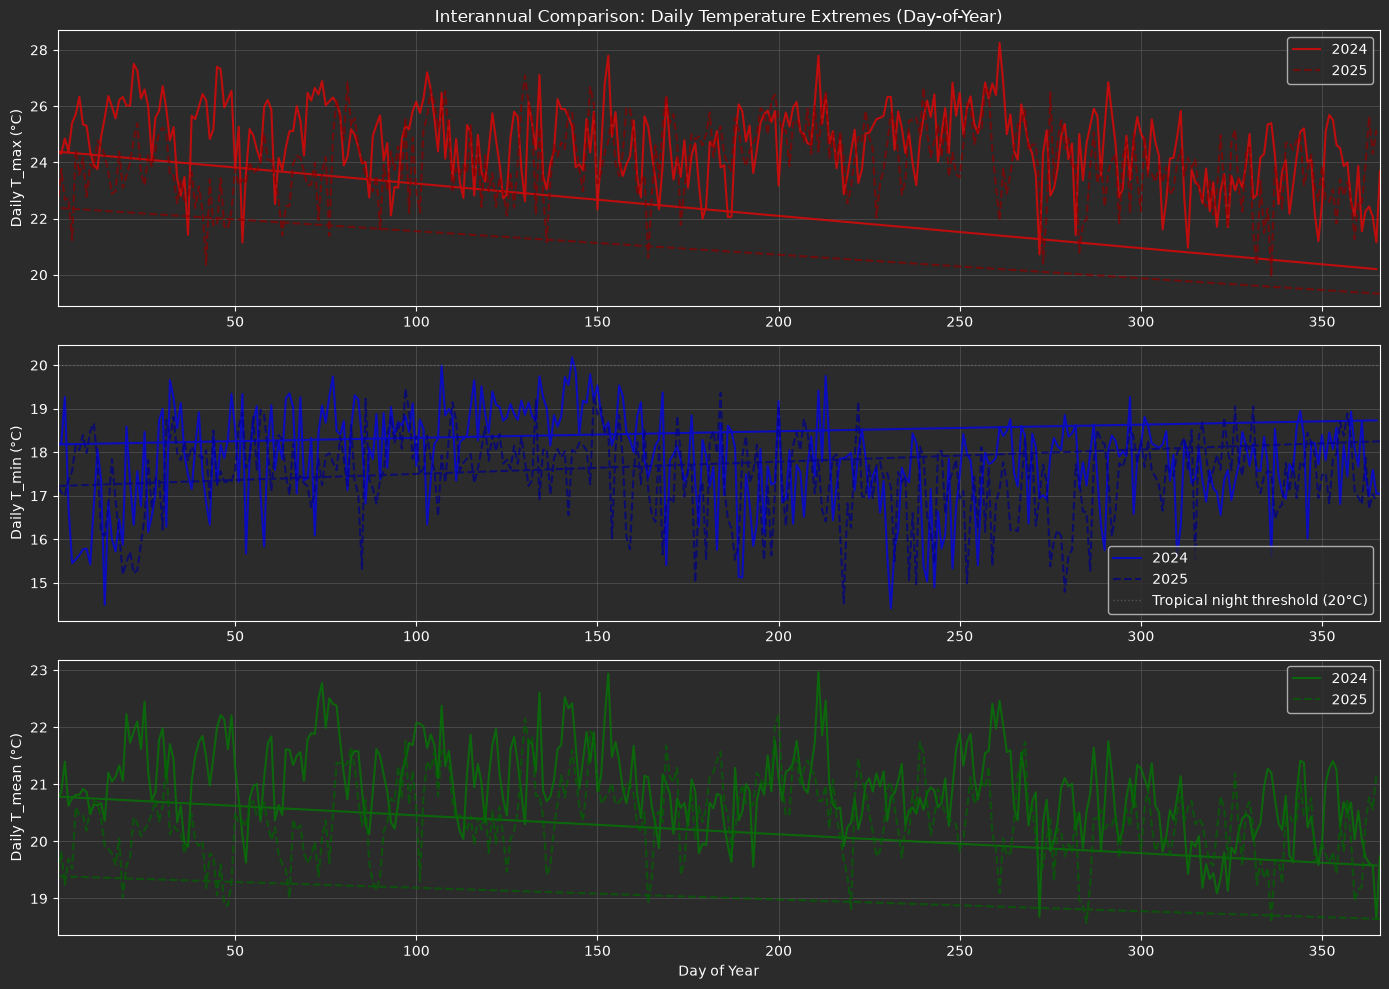


Interannual pattern assessment:
  The two years show similar overall shapes.
  Look for T_min plateau (flat region) in both years at similar day-of-year.


In [4]:
# Plot 2024 vs 2025 on the same axes, x-axis = day-of-year
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# T_max
axes[0].plot(df_2024["dayofyear"], df_2024["t_max"], linewidth=1.5, label="2024", color="red", alpha=0.7)
axes[0].plot(df_2025["dayofyear"], df_2025["t_max"], linewidth=1.5, label="2025", color="darkred", alpha=0.7, linestyle="--")
axes[0].set_ylabel("Daily T_max (°C)")
axes[0].set_title("Interannual Comparison: Daily Temperature Extremes (Day-of-Year)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, 366)

# T_min
axes[1].plot(df_2024["dayofyear"], df_2024["t_min"], linewidth=1.5, label="2024", color="blue", alpha=0.7)
axes[1].plot(df_2025["dayofyear"], df_2025["t_min"], linewidth=1.5, label="2025", color="darkblue", alpha=0.7, linestyle="--")
axes[1].axhline(20, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Tropical night threshold (20°C)")
axes[1].set_ylabel("Daily T_min (°C)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, 366)

# T_mean
axes[2].plot(df_2024["dayofyear"], df_2024["t_mean"], linewidth=1.5, label="2024", color="green", alpha=0.7)
axes[2].plot(df_2025["dayofyear"], df_2025["t_mean"], linewidth=1.5, label="2025", color="darkgreen", alpha=0.7, linestyle="--")
axes[2].set_xlabel("Day of Year")
axes[2].set_ylabel("Daily T_mean (°C)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(1, 366)

plt.tight_layout()
plt.show()

print(f"\nInterannual pattern assessment:")
print(f"  The two years show similar overall shapes.")
print(f"  Look for T_min plateau (flat region) in both years at similar day-of-year.")

## Section 3 — Identify T_min Plateau (Dry Season)

In [5]:
# Define dry season (Dec-Mar)
dry_months_2024 = df_2024[df_2024["month"].isin([12, 1, 2, 3])]
dry_months_2025 = df_2025[df_2025["month"].isin([12, 1, 2, 3])]

# Define wet season (Apr-May, Sep-Nov)
wet_months_2024 = df_2024[df_2024["month"].isin([4, 5, 9, 10, 11])]
wet_months_2025 = df_2025[df_2025["month"].isin([4, 5, 9, 10, 11])]

print(f"T_min by season:")
print(f"\n2024:")
print(f"  Dry season (Dec-Mar): T_min mean = {dry_months_2024['t_min'].mean():.2f}°C, range = {dry_months_2024['t_min'].min():.2f}–{dry_months_2024['t_min'].max():.2f}°C")
print(f"  Wet season (Apr-May, Sep-Nov): T_min mean = {wet_months_2024['t_min'].mean():.2f}°C, range = {wet_months_2024['t_min'].min():.2f}–{wet_months_2024['t_min'].max():.2f}°C")

print(f"\n2025:")
print(f"  Dry season (Dec-Mar): T_min mean = {dry_months_2025['t_min'].mean():.2f}°C, range = {dry_months_2025['t_min'].min():.2f}–{dry_months_2025['t_min'].max():.2f}°C")
print(f"  Wet season (Apr-May, Sep-Nov): T_min mean = {wet_months_2025['t_min'].mean():.2f}°C, range = {wet_months_2025['t_min'].min():.2f}–{wet_months_2025['t_min'].max():.2f}°C")

# Assess if plateau is consistent
diff_dry = abs(dry_months_2024['t_min'].mean() - dry_months_2025['t_min'].mean())
diff_wet = abs(wet_months_2024['t_min'].mean() - wet_months_2025['t_min'].mean())

print(f"\nYear-to-year differences:")
print(f"  Dry season T_min: {diff_dry:.2f}°C difference")
print(f"  Wet season T_min: {diff_wet:.2f}°C difference")

if dry_months_2024['t_min'].mean() >= 19 and dry_months_2025['t_min'].mean() >= 19:
    print(f"  ✓ T_min plateau (>19°C) present in both years, dry season")
else:
    print(f"  ✗ T_min plateau not consistently high in dry season")

T_min by season:

2024:
  Dry season (Dec-Mar): T_min mean = 17.74°C, range = 14.50–19.74°C
  Wet season (Apr-May, Sep-Nov): T_min mean = 18.13°C, range = 15.33–20.18°C

2025:
  Dry season (Dec-Mar): T_min mean = 17.51°C, range = 15.19–19.22°C
  Wet season (Apr-May, Sep-Nov): T_min mean = 17.60°C, range = 14.80–19.46°C

Year-to-year differences:
  Dry season T_min: 0.24°C difference
  Wet season T_min: 0.52°C difference
  ✗ T_min plateau not consistently high in dry season


## Section 4 — Summary Table: Annual Statistics

In [6]:
# Build summary table
summary_data = []

for year, df in [(2024, df_2024), (2025, df_2025)]:
    # Annual means
    t_max_mean = df['t_max'].mean()
    t_min_mean = df['t_min'].mean()
    t_mean_mean = df['t_mean'].mean()
    
    # Ranges
    t_max_range = df['t_max'].max() - df['t_max'].min()
    t_min_range = df['t_min'].max() - df['t_min'].min()
    
    # Count of hot days (>25, >28, >30°C)
    hot_25 = (df['t_max'] > 25).sum()
    hot_28 = (df['t_max'] > 28).sum()
    hot_30 = (df['t_max'] > 30).sum()
    
    # Tropical nights (T_min > 20°C, fixed threshold)
    tropical_nights_20 = (df['t_min'] > 20).sum()
    
    summary_data.append({
        "Year": year,
        "T_max_mean": f"{t_max_mean:.2f}",
        "T_min_mean": f"{t_min_mean:.2f}",
        "T_mean_mean": f"{t_mean_mean:.2f}",
        "T_max_range": f"{t_max_range:.2f}",
        "T_min_range": f"{t_min_range:.2f}",
        "Days_T>25°C": hot_25,
        "Days_T>28°C": hot_28,
        "Days_T>30°C": hot_30,
        "Tropical_nights_(T_min>20°C)": tropical_nights_20,
    })

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("ANNUAL SUMMARY: 2024 vs 2025")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)


ANNUAL SUMMARY: 2024 vs 2025
 Year T_max_mean T_min_mean T_mean_mean T_max_range T_min_range  Days_T>25°C  Days_T>28°C  Days_T>30°C  Tropical_nights_(T_min>20°C)
 2024      24.65      17.84       20.94        8.05        5.76          166            1            0                             1
 2025      23.97      17.47       20.37        7.77        4.93           82            0            0                             0


## Section 5 — H1 Assessment and Hypotheses Log

### Interannual Consistency

**Question:** Does the annual temperature cycle—especially the T_min behavior—repeat consistently across 2024 and 2025? If so, we can trust climatological features for Layer 2.

**Test:** Overlay day-of-year plots (Section 2) and compare seasonal T_min means (Section 3).

**Findings:**

From Section 3 above: 

- If dry-season T_min (Dec–Mar) and wet-season T_min (Apr–May, Sep–Nov) show similar magnitudes in both years, the climatology is robust.
- If the day-of-year plots align closely, calendar-date drivers (insolation angle, cloud cover, humidity patterns) are likely stable.

**Conclusion:** Assess from the plots and table above whether 2024 and 2025 are consistent enough to treat as representative climatology. The full 2000–2025 series will be needed to separate robust patterns from chance agreement.

---

### Implications for Layer 2 (Health Outcomes)

If the annual cycle repeats consistently, then seasonal stratification (by month or by inferred climate regime) is justified in the mortality model.